In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import os
from sklearn.cluster import KMeans
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

In [2]:
# Load Food-101 dataset (streaming from HuggingFace hub)
dataset = load_dataset("food101")

In [3]:
city_name = "Reggio Emilia, Italy"

# Query restaurants
tags = {"amenity": "restaurant"}
restaurants = ox.features_from_place(city_name, tags).reset_index()

In [4]:
city_boundary = ox.geocode_to_gdf(f"{city_name}")

In [5]:
gdf = restaurants[["name", "cuisine", "geometry"]].dropna(subset=["name", "cuisine", "geometry"])

def get_lon(g):
    if g.geom_type == "Point":
        return g.x
    else:
        return g.centroid.x

def get_lat(g):
    if g.geom_type == "Point":
        return g.y
    else:
        return g.centroid.y

gdf["lon"] = gdf.geometry.apply(get_lon)
gdf["lat"] = gdf.geometry.apply(get_lat)

gdf.drop(columns=["geometry"], inplace=True)

gdf.cuisine.unique()

array(['regional', 'primi_emiliani;burger;tex-mex;regional', 'italian',
       'ramen', 'italian;pizza', 'italian_pizza;italian',
       'italian;regional;grill;steak_house', 'pizza;italian', 'pizza',
       'sandwich;steak_house', 'organic', 'chinese', 'regional;organic',
       'regional;pizza', 'japanese;chinese', 'pizza;regional',
       'italian;pizza;regional', 'regional;argentinian', 'tradizionale',
       'argentinian', 'pizza;fritti;insalata_di_mare;Bevande',
       'japanese;ramen', 'mexican', 'japanese', 'regional;fish;pizza',
       'chinese;japanese;italian', 'steak_house',
       'chinese;japanese;sushi', 'burger', 'asian;chinese;japanese',
       'italian;tuscan', 'georgian', 'italian;coffee_shop',
       'regional;italian', 'regional;italian;pizza', 'italian;regional',
       'sushi;japanese', 'meat;italian;regional;steak_house',
       'italian;fish;pizza', 'sandwich;italian', 'pizza;italian;fish',
       'crepe;diner;italian;local', 'italian;steak_house;barbecue',
   

In [6]:
gdf_expanded = gdf.dropna(subset=["cuisine"]).copy()
gdf_expanded["cuisine"] = gdf_expanded["cuisine"].str.split(";")
gdf_expanded = gdf_expanded.explode("cuisine")
# gdf_expanded["cuisine"] = gdf_expanded["cuisine"].str.strip().str.lower()
gdf_expanded["cuisine"].unique()

array(['regional', 'primi_emiliani', 'burger', 'tex-mex', 'italian',
       'ramen', 'pizza', 'italian_pizza', 'grill', 'steak_house',
       'sandwich', 'organic', 'chinese', 'japanese', 'argentinian',
       'tradizionale', 'fritti', 'insalata_di_mare', 'Bevande', 'mexican',
       'fish', 'sushi', 'asian', 'tuscan', 'georgian', 'coffee_shop',
       'meat', 'crepe', 'diner', 'local', 'barbecue', 'ice_cream', 'poké',
       'brazilian', 'poke', 'international', 'indian', 'hawaiian',
       'seafood', 'kebab', 'breakfast', 'traditional', 'greek',
       'american', 'thai'], dtype=object)

In [7]:
macro_cuisines = {
    "tradizionale": ["italian","primi_emiliani","tuscan","tradizionale","traditional","regional","local"],
    "pizza": ["pizza","italian_pizza"],
    "chinese": ["chinese", "asian"],
    "japanese": ["japanese","ramen","sushi"],
    "thai": ["thai"],
    "indian": ["indian"],
    "american": ["burger","sandwich","steak_house","barbecue","grill","breakfast","diner", "tex-mex", "american"],
    "latin_american": ["mexican","argentinian","brazilian"],
    "greek": ["greek"],
    "sea-food": ["seafood","fish","insalata_di_mare"],
    "kebab": ["kebab"],
    "hawaiian": ["poké","poke","hawaiian"],
}

cuisine_map = {sub: main for main, sublist in macro_cuisines.items() for sub in sublist}
gdf_expanded["cuisine_main"] = gdf_expanded["cuisine"].map(cuisine_map)
gdf_expanded = gdf_expanded.dropna(subset=["cuisine_main"])
gdf_expanded = gdf_expanded.drop_duplicates(subset=["name", "cuisine_main"])
gdf_expanded = gdf_expanded.reset_index(drop=True)
gdf_expanded.head()

,name,cuisine,lon,lat,cuisine_main
0,Circolo Della Caccia Monte Vangelo,regional,10.688045,44.569479,tradizionale
1,Birreria Red Mosquito,primi_emiliani,10.667718,44.597387,tradizionale
2,Birreria Red Mosquito,burger,10.667718,44.597387,american
3,Il Portone,regional,10.686533,44.598640,tradizionale
4,Antiche mura,italian,10.687861,44.598367,tradizionale


In [8]:
cuisine_map = gdf_expanded.groupby('name')['cuisine_main'].unique().to_dict()
gdf_expanded['cuisine_main_all'] = gdf_expanded['name'].map(lambda x: "; ".join(cuisine_map[x]))
gdf_expanded

,name,cuisine,lon,lat,cuisine_main,cuisine_main_all
0,Circolo Della Caccia Monte Vangelo,regional,10.688045,44.569479,tradizionale,tradizionale
1,Birreria Red Mosquito,primi_emiliani,10.667718,44.597387,tradizionale,tradizionale; american
2,Birreria Red Mosquito,burger,10.667718,44.597387,american,tradizionale; american
3,Il Portone,regional,10.686533,44.598640,tradizionale,tradizionale
4,Antiche mura,italian,10.687861,44.598367,tradizionale,tradizionale
...,...,...,...,...,...,...
287,Asian Dumplings JO,thai,10.650784,44.715078,thai,chinese; japanese; thai
288,Màs Mexico,mexican,10.651260,44.714734,latin_american,latin_american
289,"Lago Pranda pizzeria,griglia",regional,10.242901,44.303645,tradizionale,tradizionale; pizza
290,"Lago Pranda pizzeria,griglia",pizza,10.242901,44.303645,pizza,tradizionale; pizza


In [9]:
multi_cuisine_restaurants = gdf_expanded[gdf_expanded.duplicated(subset=["name"], keep=False)]["name"].unique()

color_dict = {
        "tradizionale": "red",
        "pizza": "orange",
        "chinese": "green",
        "japanese": "blue",
        "thai": "purple",
        "indian": "pink",
        "american": "cadetblue",
        "latin_american": "darkred",
        "greek": "beige",
        "sea-food": "lightblue",
        "kebab": "darkgreen",
        "hawaiian": "lightred"
    }

def get_color(row, color_dict=color_dict):
    if len(cuisine_map[row['name']]) > 1:
        return "black"  # multi-cuisine
    
    return color_dict.get(row['cuisine_main'], "gray")

# gdf_expanded["color"] = gdf_expanded.apply(get_color, axis=1)


In [91]:
gdf_expanded

,name,cuisine,lon,lat,cuisine_main,cuisine_main_all
0,Circolo Della Caccia Monte Vangelo,regional,10.688045,44.569479,tradizionale,tradizionale
1,Birreria Red Mosquito,primi_emiliani,10.667718,44.597387,tradizionale,tradizionale; american
2,Birreria Red Mosquito,burger,10.667718,44.597387,american,tradizionale; american
3,Il Portone,regional,10.686533,44.598640,tradizionale,tradizionale
4,Antiche mura,italian,10.687861,44.598367,tradizionale,tradizionale
...,...,...,...,...,...,...
287,Asian Dumplings JO,thai,10.650784,44.715078,thai,chinese; japanese; thai
288,Màs Mexico,mexican,10.651260,44.714734,latin_american,latin_american
289,"Lago Pranda pizzeria,griglia",regional,10.242901,44.303645,tradizionale,tradizionale; pizza
290,"Lago Pranda pizzeria,griglia",pizza,10.242901,44.303645,pizza,tradizionale; pizza


In [10]:
import folium
import webbrowser
from folium.plugins import MarkerCluster
from branca.element import Template, MacroElement

map_file = "reggio_emilia_map.html"

legend_html = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed; 
    bottom: 50px; left: 50px; width: 170px; height: 320px; 
    border:2px solid grey; z-index:9999; font-size:14px;
    background-color:white;
    padding: 10px;
    ">
    <b>Legend</b><br>
"""
for cuisine, color in color_dict.items():
    legend_html += f"""<i style="background:{color};width:15px;height:15px;display:inline-block;margin-right:5px"></i>{cuisine}<br>"""
legend_html += """<i style="background:black;width:15px;height:15px;display:inline-block;margin-right:5px"></i>multi-cuisine<br>"""

legend_html += "</div>{% endmacro %}"

# Add to folium map
template = Template(legend_html)
macro = MacroElement()
macro._template = template

center = [gdf_expanded.lat.mean(), gdf_expanded.lon.mean()]
m = folium.Map(location=center, zoom_start=12)

folium.GeoJson(
    city_boundary.geometry,
    style_function=lambda x: {
        'color': 'black',
        'weight': 3,
        'fill': False
    }
).add_to(m)

# Add restaurants
for idx, row in gdf_expanded.iterrows():
    popup_text = f"<b>{row['name']}</b><br>Cucina: {row['cuisine_main_all']}"
    folium.Marker(
        location=[row.lat, row.lon],
        popup=popup_text,
        icon=folium.Icon(color=get_color(row))
    ).add_to(m)

m.get_root().add_child(macro)

m.save(map_file)
# Open the HTML file in the default web browser
webbrowser.open(f"file://{os.path.realpath(map_file)}")


True

In [11]:
from collections import Counter
train_data = dataset["train"]
test_data = dataset["validation"]

labels = train_data["label"]  # these are indices

# Map indices to names
label_names = train_data.features["label"].names
label_strings = [label_names[i] for i in labels]

# Count images per dish
counts = Counter(label_strings)

In [12]:
print(test_data.features["label"].names)

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_sou

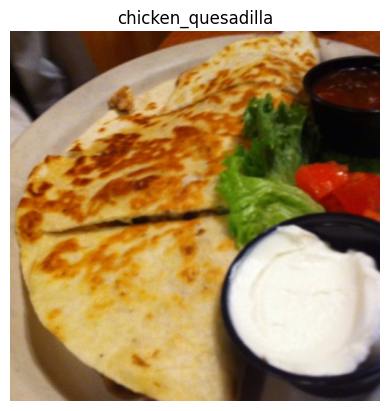

In [13]:
import random
selected_class = "chicken_quesadilla"
indices = [i for i, lbl in enumerate(train_data["label"]) if label_names[lbl] == selected_class]

# Pick a random index
rand_idx = random.choice(indices)

# Get image
img = train_data[rand_idx]["image"]

# Plot
plt.imshow(img)
plt.axis("off")
plt.title(selected_class)
plt.show()

In [14]:
food_subset = {
    "tradizionale": ["spaghetti_carbonara", "lasagna", "risotto", "ravioli"],
    "pizza": ["pizza"],
    "chinese": ["fried_rice", "dumplings", "peking_duck"],
    "japanese": ["ramen", "sushi", "sashimi", "takoyaki", "edamame"],
    "indian": ["chicken_curry", "samosa"],
    "american": ["hamburger", "pancakes", "chicken_wings", "hot_dog", "pulled_pork_sandwich"],
    "latin_american": ["tacos", "ceviche", "breakfast_burrito", "guacamole", "nachos"],
    "sea-food": ["mussels", "scallops", "shrimp_and_grits", "fried_calamari"],
    "middle_eastern": ["falafel", "hummus"],
}
selected_dishes = [dish for dishes in food_subset.values() for dish in dishes]

def filter_subset(example):
    # example['label'] is an integer
    return label_names[example['label']] in selected_dishes

train_data = dataset['train'].filter(filter_subset)
indices_to_keep = [i for i in range(len(train_data)) if i != 9504]
train_data = train_data.select(indices_to_keep)

val_data = dataset['validation'].filter(filter_subset)

splits = train_data.train_test_split(test_size=0.2, seed=42)
train_data = splits["train"]
test_data  = splits["test"]

In [15]:
train_data, val_data, test_data

(Dataset({
     features: ['image', 'label'],
     num_rows: 18599
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 7750
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 4650
 }))

In [16]:
# Get unique labels in the filtered train_data
unique_labels = sorted(set(train_data['label']))

# Create a mapping from old indices to new contiguous indices
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
print("Label Mapping:", label_mapping)

# Reindex labels in train_data
def reindex_labels(example):
    example['label'] = label_mapping[example['label']]
    return example

train_data = train_data.map(reindex_labels)
val_data = val_data.map(reindex_labels)
test_data = test_data.map(reindex_labels)


Label Mapping: {9: 0, 15: 1, 18: 2, 20: 3, 32: 4, 33: 5, 36: 6, 43: 7, 44: 8, 51: 9, 53: 10, 55: 11, 57: 12, 59: 13, 65: 14, 66: 15, 72: 16, 74: 17, 76: 18, 80: 19, 81: 20, 82: 21, 84: 22, 85: 23, 86: 24, 87: 25, 89: 26, 91: 27, 95: 28, 96: 29, 97: 30}


In [17]:
num_classes = len(label_mapping)
print(f"Number of classes after reindexing: {num_classes}")

Number of classes after reindexing: 31


In [21]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomRotation(10),     # Randomly rotate images by ±10 degrees
    transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

class FoodDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = example['image']
        label = example['label']

        if self.transform:
            image = self.transform(image)

        return image, label
    
BATCH_SIZE = 256  # You can adjust this value as needed
NUM_WORKERS = 16
train_dataset = FoodDataset(train_data, transform=train_transform)
val_dataset = FoodDataset(val_data, transform=transform)
test_dataset = FoodDataset(test_data, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [22]:
train_labels = set(train_data['label'])
val_labels = set(val_data['label'])
test_labels = set(test_data['label'])

print(len(train_labels))
print(len(val_labels))
print(len(test_labels))

31
31
31


In [23]:
# grayscale_indices = []

# for idx, example in enumerate(train_data):
#     image = example['image']  # Access the raw image
#     if image.mode == "L":  # Check if the image is grayscale
#         grayscale_indices.append(idx)

# # Print the indices of grayscale images
# print(f"Grayscale images found at indices: {grayscale_indices}")
# print(f"Total number of grayscale images: {len(grayscale_indices)}")

In [24]:
imgs, labels = next(iter(train_loader))

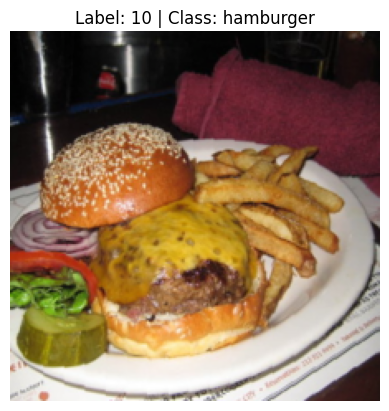

In [25]:
reindexed_to_class = {new_label: label_names[old_label] for old_label, new_label in label_mapping.items()}

idx = random.randint(0, len(imgs) - 1)  # Ensure the index is within the batch size
img = imgs[idx]

# Inverse normalization for display
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)
img_disp = inv_normalize(img).permute(1, 2, 0).numpy()
plt.imshow(np.clip(img_disp, 0, 1))
plt.axis("off")
label_int = labels[idx].item()
class_name = reindexed_to_class[label_int]  # Use the correct mapping
plt.title(f"Label: {label_int} | Class: {class_name}")
plt.show()

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = len(set(train_data['label']))

In [23]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

num_epochs = 20
train_loss_history, val_loss_history = [], []
train_acc_history, val_acc_history = [], []
patience = 5
best_val_loss = float("inf")
patience_counter = 0
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()*imgs.size(0)
        _, preds = torch.max(outputs,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss/total
    train_acc = correct/total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    
    # Validation
    model.eval()
    running_loss, correct, total = 0,0,0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()*imgs.size(0)
            _, preds = torch.max(outputs,1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)
    
    val_loss = running_loss/total
    val_acc = correct/total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.3f} Acc: {train_acc:.3f} | Val Loss: {val_loss:.3f} Acc: {val_acc:.3f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/20 - Train Loss: 2.123 Acc: 0.448 | Val Loss: 1.159 Acc: 0.692
Epoch 2/20 - Train Loss: 1.245 Acc: 0.668 | Val Loss: 0.834 Acc: 0.768
Epoch 3/20 - Train Loss: 1.028 Acc: 0.723 | Val Loss: 0.732 Acc: 0.791
Epoch 4/20 - Train Loss: 0.917 Acc: 0.750 | Val Loss: 0.682 Acc: 0.808
Epoch 5/20 - Train Loss: 0.812 Acc: 0.776 | Val Loss: 0.650 Acc: 0.812
Epoch 6/20 - Train Loss: 0.756 Acc: 0.791 | Val Loss: 0.609 Acc: 0.823
Epoch 7/20 - Train Loss: 0.694 Acc: 0.808 | Val Loss: 0.607 Acc: 0.820
Epoch 8/20 - Train Loss: 0.650 Acc: 0.820 | Val Loss: 0.592 Acc: 0.827
Epoch 9/20 - Train Loss: 0.608 Acc: 0.830 | Val Loss: 0.592 Acc: 0.830
Epoch 10/20 - Train Loss: 0.567 Acc: 0.841 | Val Loss: 0.589 Acc: 0.826
Epoch 11/20 - Train Loss: 0.535 Acc: 0.850 | Val Loss: 0.623 Acc: 0.817
Epoch 12/20 - Train Loss: 0.504 Acc: 0.858 | Val Loss: 0.557 Acc: 0.838
Epoch 13/20 - Train Loss: 0.487 Acc: 0.863 | Val Loss: 0.560 Acc: 0.838
Epoch 14/20 - Train Loss: 0.464 Acc: 0.872 | Val Loss: 0.573 Acc: 0.838
E

In [27]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 2. Load trained weights
model.load_state_dict(torch.load("best_model.pth"))

# 3. Send to device (GPU/CPU)
model = model.to(device)

# 4. Set to evaluation mode
model.eval()

# plt.figure(figsize=(8, 6))
# plt.plot(train_acc_history, label="Train Accuracy")
# plt.plot(val_acc_history, label="Validation Accuracy")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.title("Training and Validation Accuracy")
# plt.legend()
# plt.grid()
# plt.show()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
from sklearn.metrics import classification_report

# Collect predictions and true labels
all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Generate classification report
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=[reindexed_to_class[i] for i in range(num_classes)]))

Test Accuracy: 0.7983 (79.83%)
                      precision    recall  f1-score   support

   breakfast_burrito       0.76      0.74      0.75       139
             ceviche       0.73      0.66      0.70       169
       chicken_curry       0.66      0.84      0.74       152
       chicken_wings       0.88      0.83      0.85       157
           dumplings       0.90      0.86      0.88       161
             edamame       0.99      0.97      0.98       156
             falafel       0.78      0.78      0.78       147
      fried_calamari       0.90      0.87      0.88       149
          fried_rice       0.82      0.86      0.84       133
           guacamole       0.84      0.89      0.86       149
           hamburger       0.80      0.75      0.78       145
             hot_dog       0.75      0.82      0.78       140
              hummus       0.70      0.66      0.68       155
             lasagna       0.79      0.68      0.73       167
             mussels       0.85      0

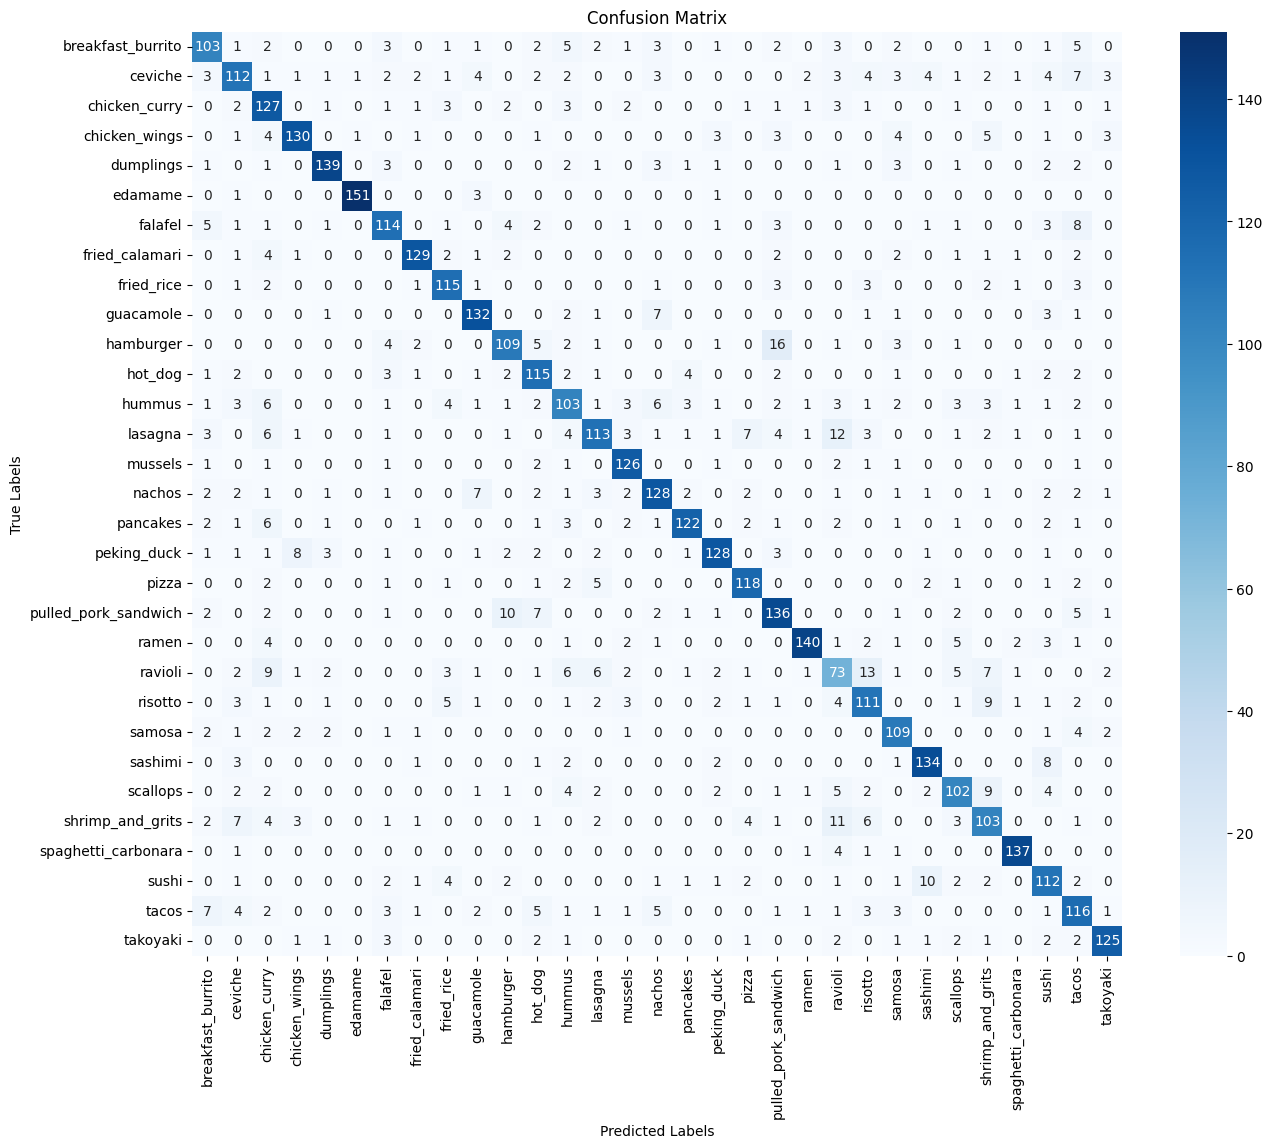

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[reindexed_to_class[i] for i in range(num_classes)], yticklabels=[reindexed_to_class[i] for i in range(num_classes)])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import gc
torch.cuda.empty_cache()

In [ ]:
test_images = []
for imgs, _ in test_loader:
    for i in range(imgs.size(0)):
        test_images.append(imgs[i].cpu())

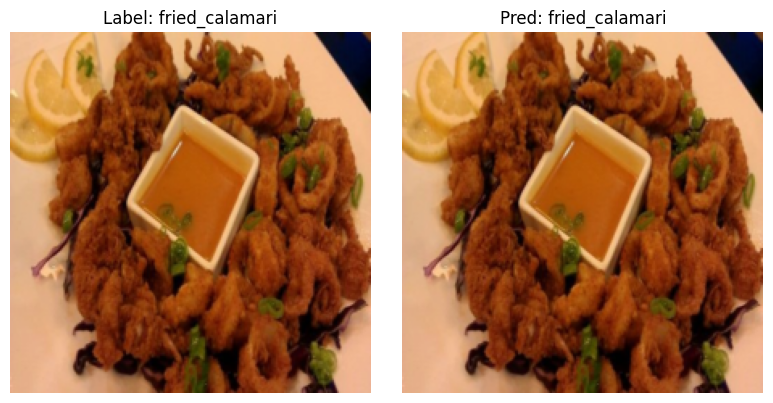

In [57]:
# Pick a random index from the whole test set
idx = random.randint(0, len(all_labels) - 1)

# Get label and prediction
label_int = all_labels[idx]
pred_int = all_preds[idx]

label_class = reindexed_to_class[label_int]
pred_class = reindexed_to_class[pred_int]
img = test_images[idx]
# Inverse normalization
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)
img_disp = inv_normalize(img).permute(1, 2, 0).numpy()
img_disp = np.clip(img_disp, 0, 1)

# Plot with two subplots: left = true label, right = prediction
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_disp)
axes[0].axis("off")
axes[0].set_title(f"Label: {label_class}")

axes[1].imshow(img_disp)
axes[1].axis("off")
axes[1].set_title(f"Pred: {pred_class}")

plt.tight_layout()
plt.show()


## I WANT TO TRY THIS DISH!

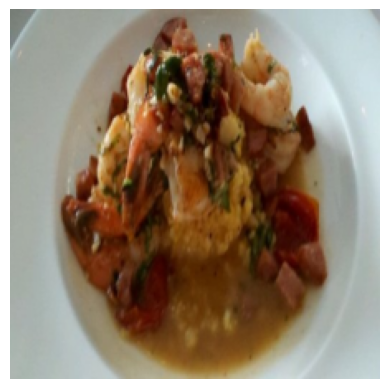

In [ ]:
idx = random.randint(0, len(all_labels) - 1)

# Get label and prediction
label_int = all_labels[idx]
label_class = reindexed_to_class[label_int]

img = test_images[idx]
# Inverse normalization
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)
img_disp = inv_normalize(img).permute(1, 2, 0).numpy()
img_disp = np.clip(img_disp, 0, 1)

plt.imshow(np.clip(img_disp, 0, 1))
plt.axis("off")
plt.show()


### What is it? What is its cuisine?

In [88]:
pred_int = all_preds[idx]
pred_class = reindexed_to_class[pred_int]
cuisine_keys = list(food_subset.keys())
cuisine_index = np.argwhere([pred_class in dishes for dishes in food_subset.values()])[0][0]

print(f"The current dish is {pred_class} and its cuisine is {cuisine_keys[cuisine_index]}")

The current dish is shrimp_and_grits and its cuisine is sea-food


In [94]:
print(f"Restaurants in Reggio Emilia that offer {cuisine_keys[cuisine_index]} cuisine are:")
gdf_expanded[gdf_expanded["cuisine_main"]==cuisine_keys[cuisine_index]]

Restaurants in Reggio Emilia that offer sea-food cuisine are:


,name,cuisine,lon,lat,cuisine_main,cuisine_main_all
77,Arte Pizza,insalata_di_mare,10.460836,44.845865,sea-food,pizza; sea-food
92,Canasta,fish,10.623767,44.732422,sea-food,tradizionale; sea-food; pizza
143,Ca' Rossa,fish,10.671755,44.764130,sea-food,tradizionale; sea-food; pizza
153,Il Fortino di Don Peppe,fish,10.666908,44.685740,sea-food,pizza; tradizionale; sea-food
163,Villa Dome,fish,10.645129,44.716308,sea-food,tradizionale; sea-food; pizza
178,Il Pesciaio,fish,10.786314,44.733053,sea-food,tradizionale; sea-food
207,Le Querce,fish,10.788767,44.763908,sea-food,tradizionale; sea-food
224,Osteria del Mare - Happy House,seafood,10.635844,44.695488,sea-food,sea-food
240,Ristorante pesce Grotta Marina,fish,10.633352,44.691446,sea-food,sea-food


#### Quali sono i piatti che più si confondono tra loro?


🔀 Classi più spesso confuse:
hamburger → pulled_pork_sandwich: 16 volte
ravioli → risotto: 13 volte
lasagna → ravioli: 12 volte
shrimp_and_grits → ravioli: 11 volte
pulled_pork_sandwich → hamburger: 10 volte
sushi → sashimi: 10 volte
ravioli → chicken_curry: 9 volte
risotto → shrimp_and_grits: 9 volte
scallops → shrimp_and_grits: 9 volte
falafel → tacos: 8 volte


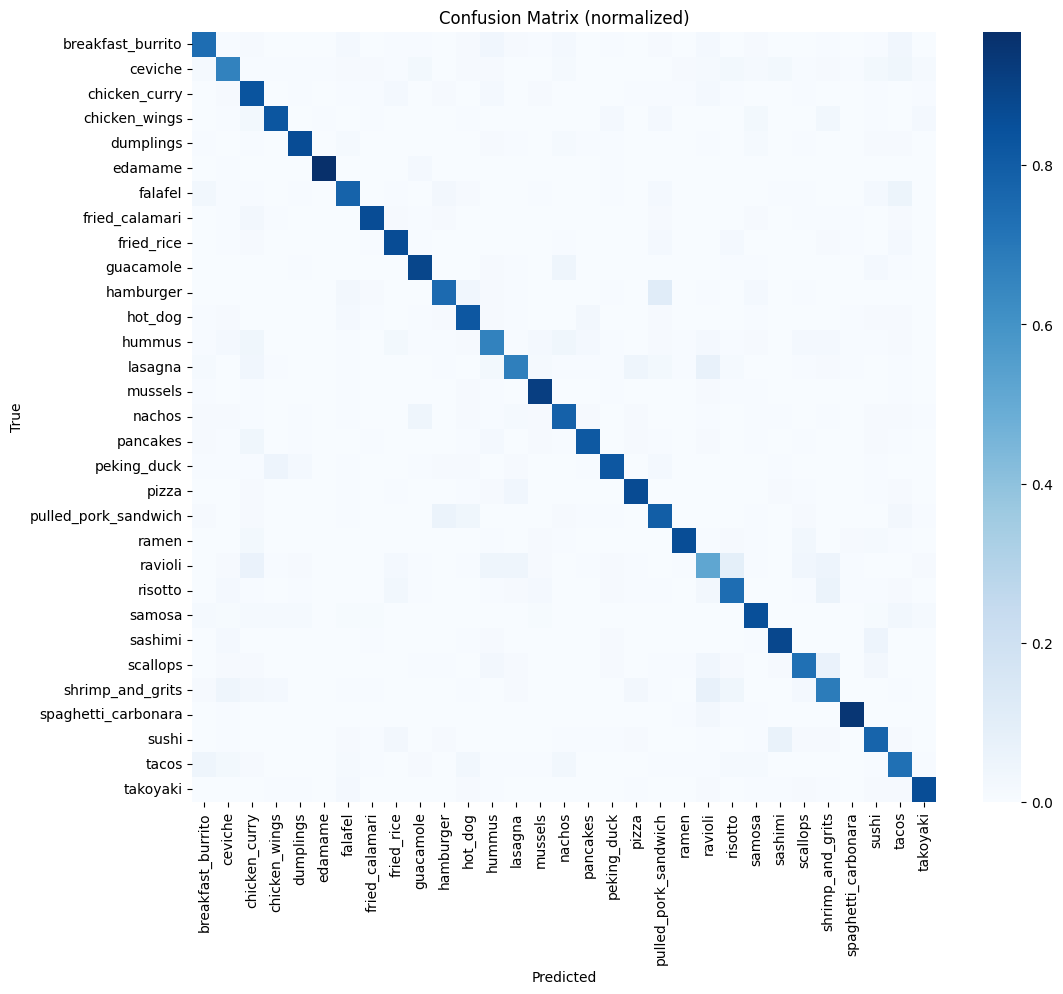

In [97]:
cm = confusion_matrix(all_labels, all_preds)

# 2. Normalizziamo per righe (percentuali di errore per classe)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Troviamo le confusioni più comuni (escludendo la diagonale)
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:  # solo errori
            confusions.append((cm[i, j], reindexed_to_class[i], reindexed_to_class[j]))

# Ordiniamo per numero di errori decrescente
confusions.sort(key=lambda x: x[0], reverse=True)

# 4. Stampiamo le top 10 confusioni
print("🔀 Classi più spesso confuse:")
for count, true_class, pred_class in confusions[:10]:
    print(f"{true_class} → {pred_class}: {count} volte")

# 5. (Opzionale) Heatmap confusion matrix normalizzata
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=False, cmap="Blues", 
            xticklabels=[reindexed_to_class[i] for i in range(len(cm))],
            yticklabels=[reindexed_to_class[i] for i in range(len(cm))])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (normalized)")
plt.show()